# Analyzes mean and avg of the GENERATED connectomes 

Grouped Statistics by Eta and Gamma:
     eta gamma  \
                 
0      0     0   
1      0     1   
2      0     2   
3      0     3   
4      0     4   
...   ..   ...   
9995  99    95   
9996  99    96   
9997  99    97   
9998  99    98   
9999  99    99   

     MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)  \
                                                                 mean   
0                                              0.834444                 
1                                              0.830000                 
2                                              0.834444                 
3                                              0.824444                 
4                                              0.832222                 
...                                                 ...                 
9995                                           0.960000                 
9996                                           0.926667                

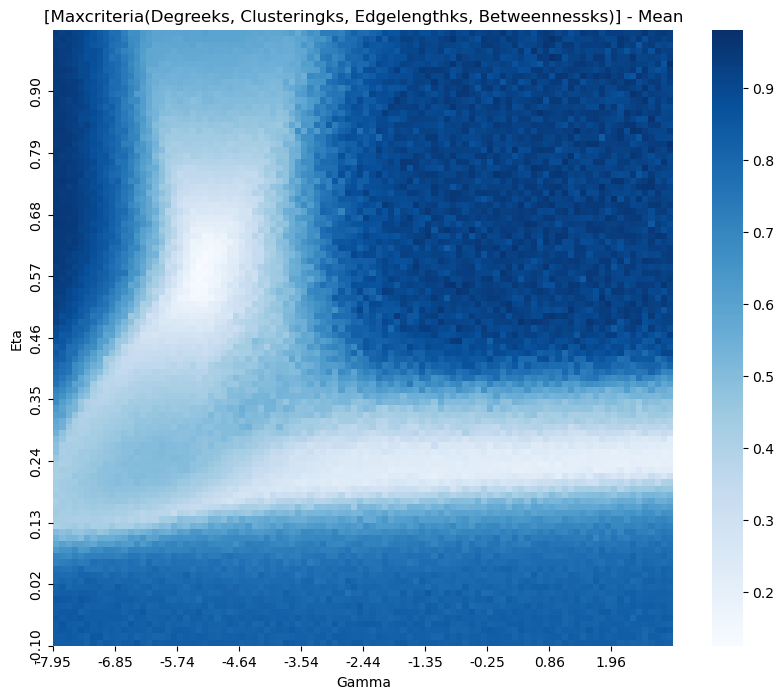

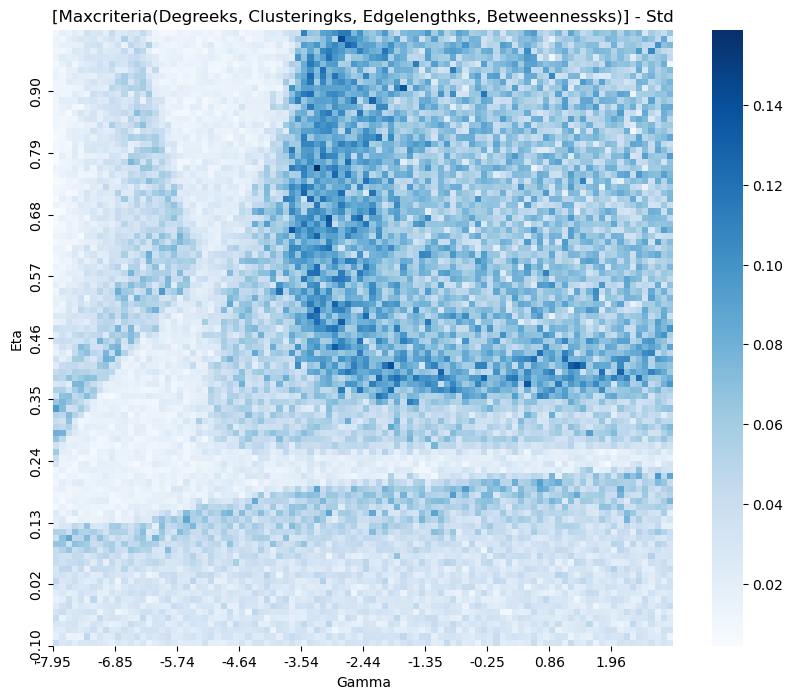

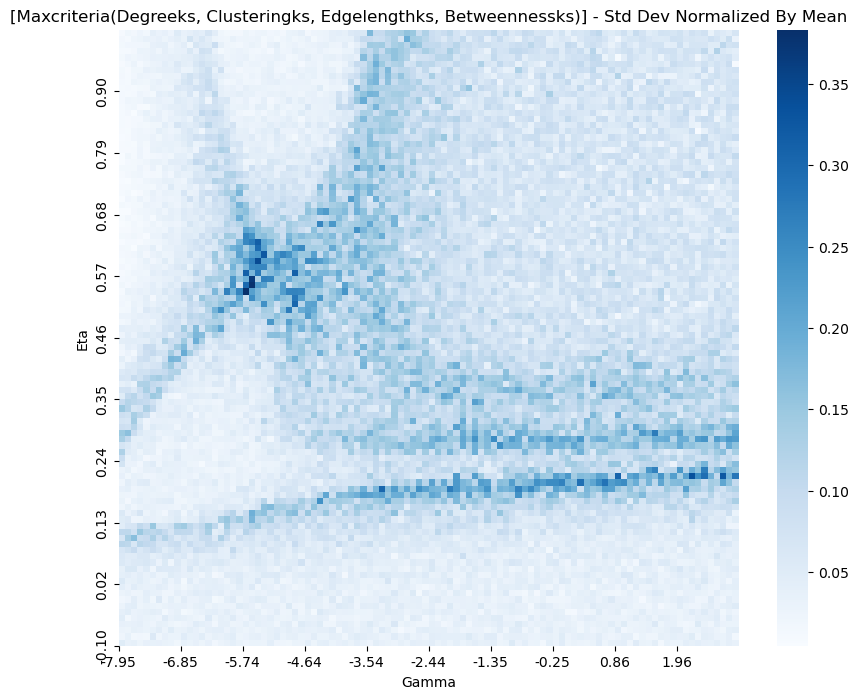

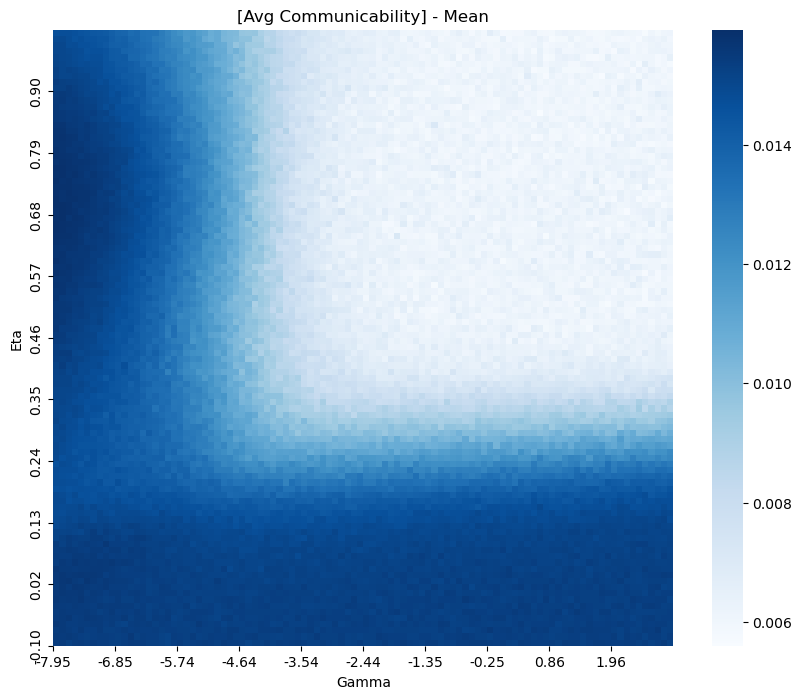

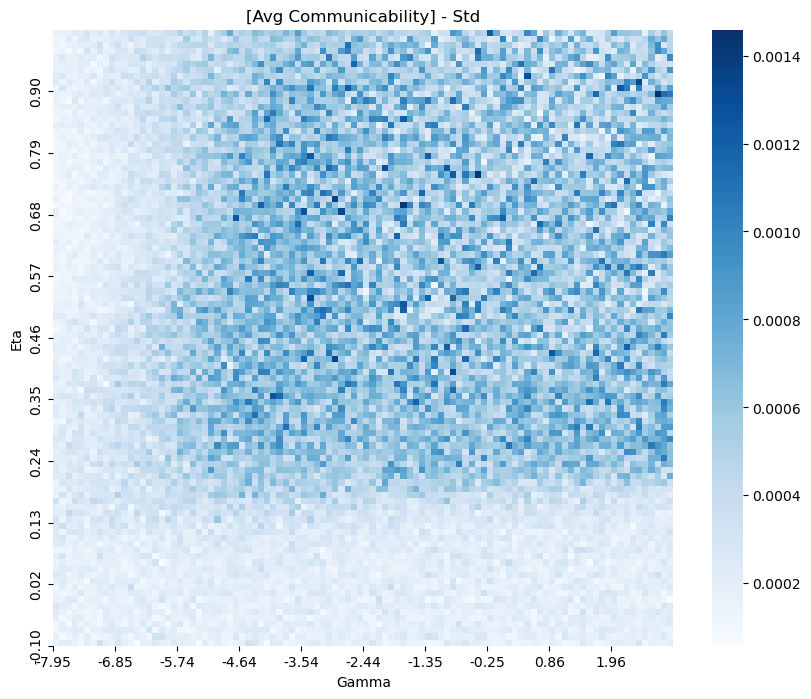

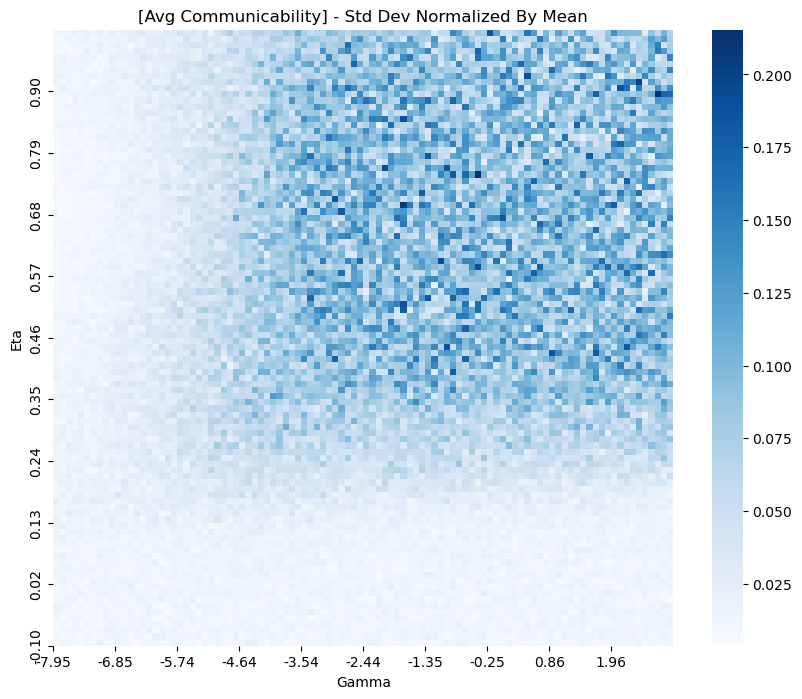

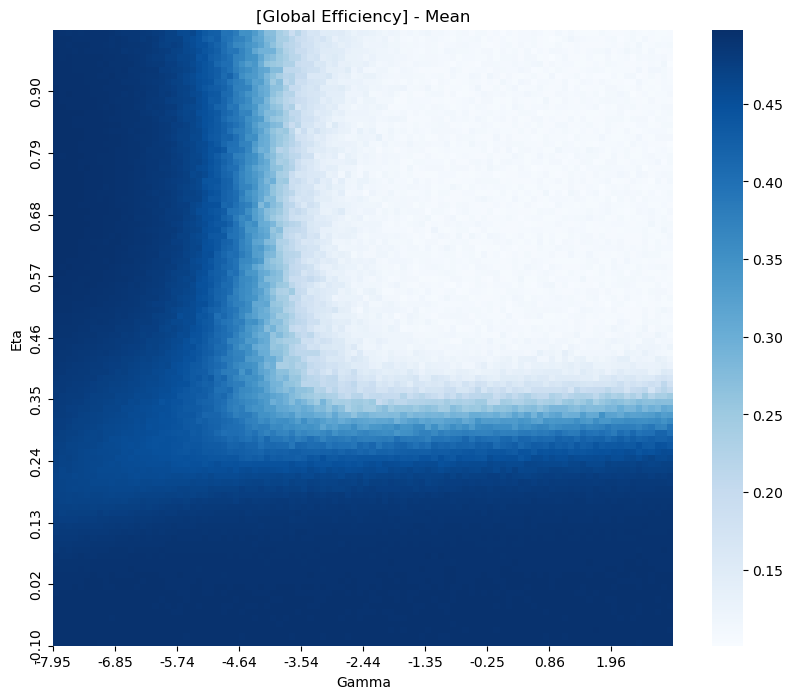

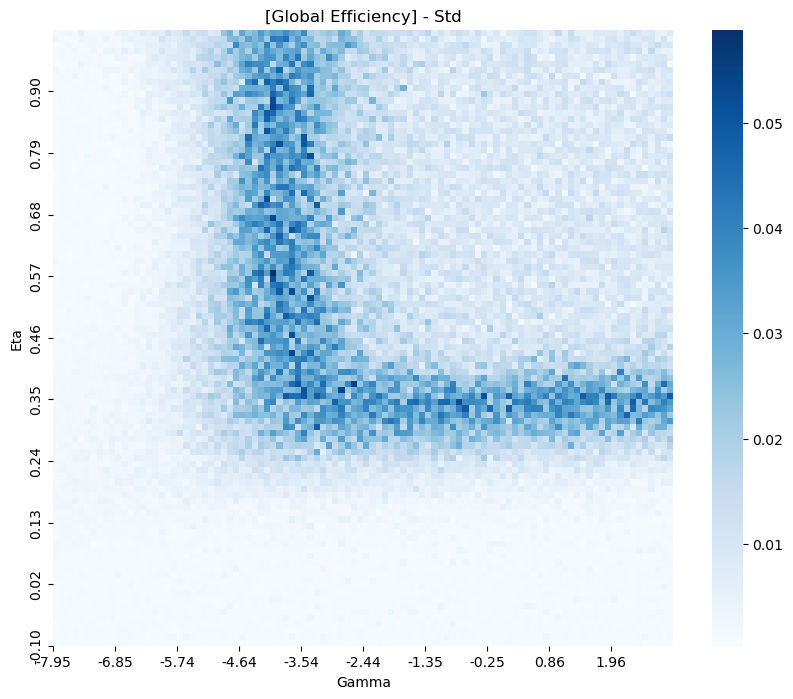

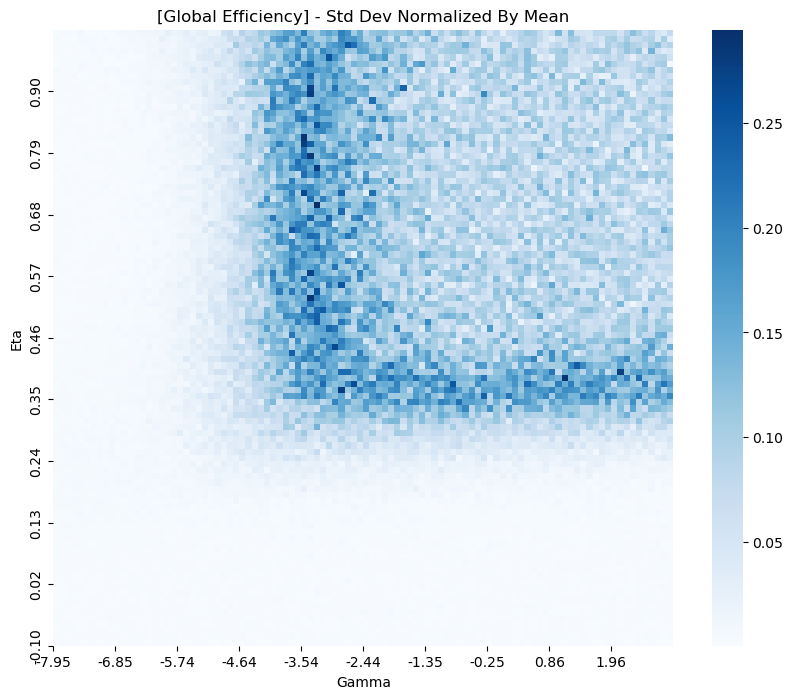

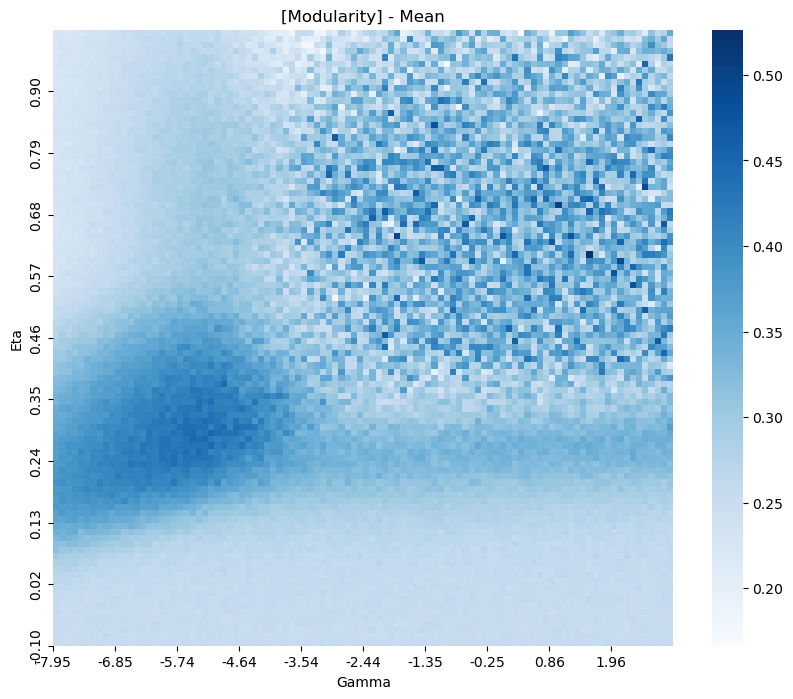

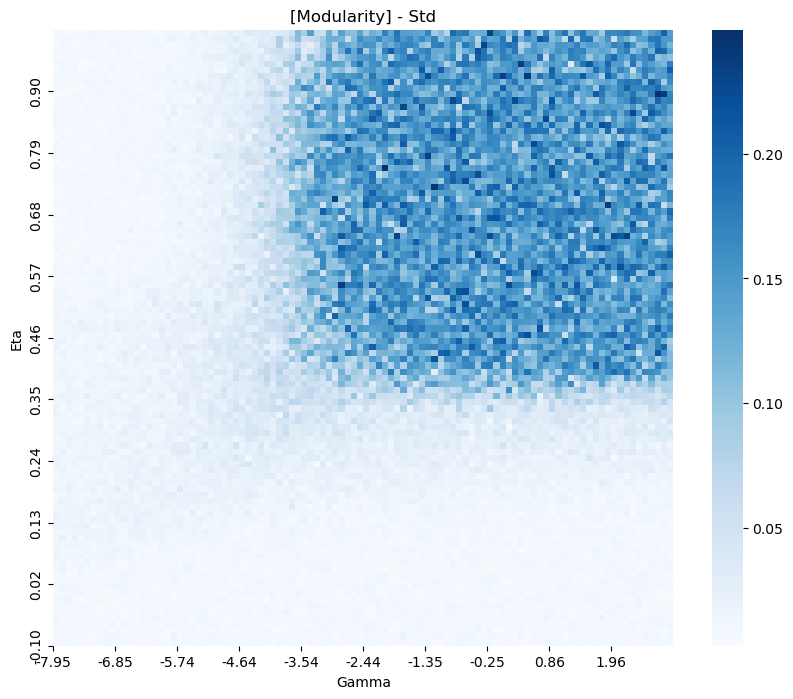

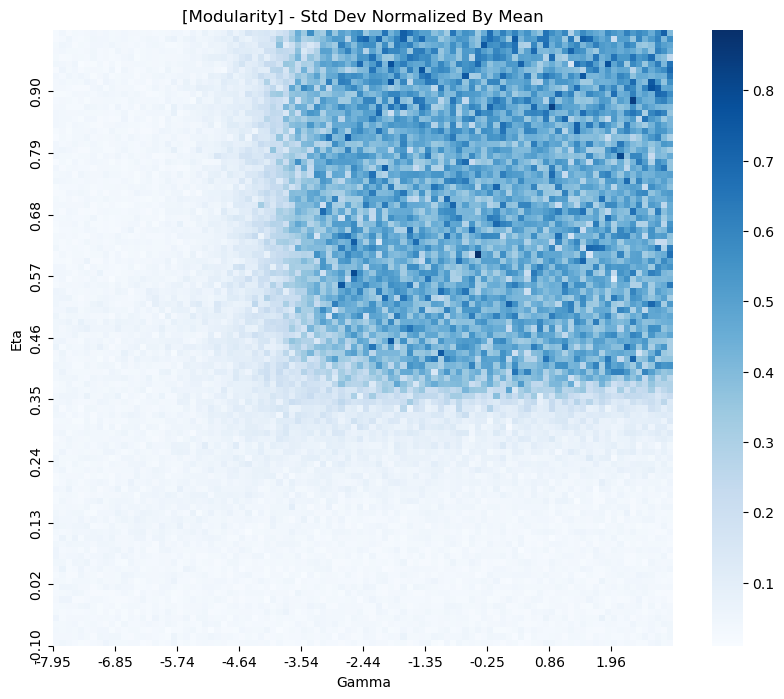

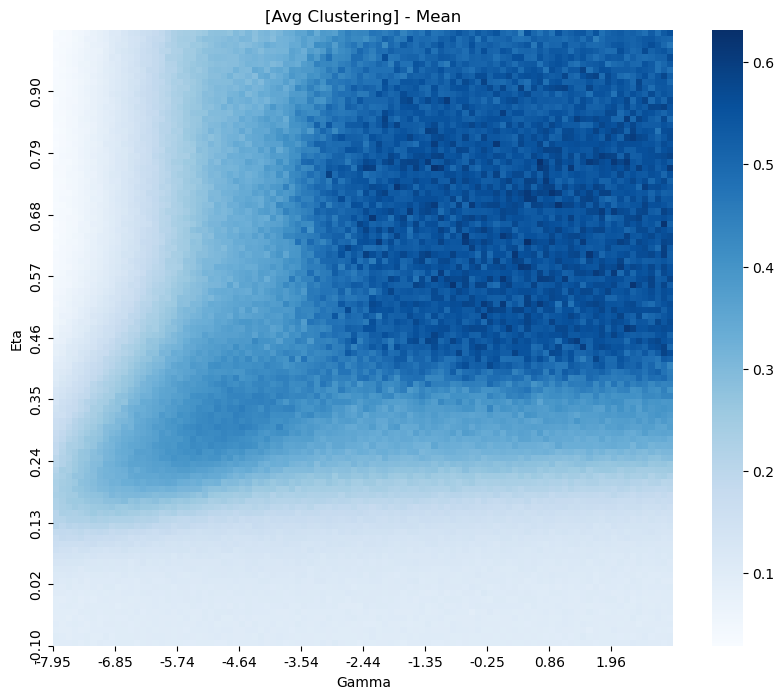

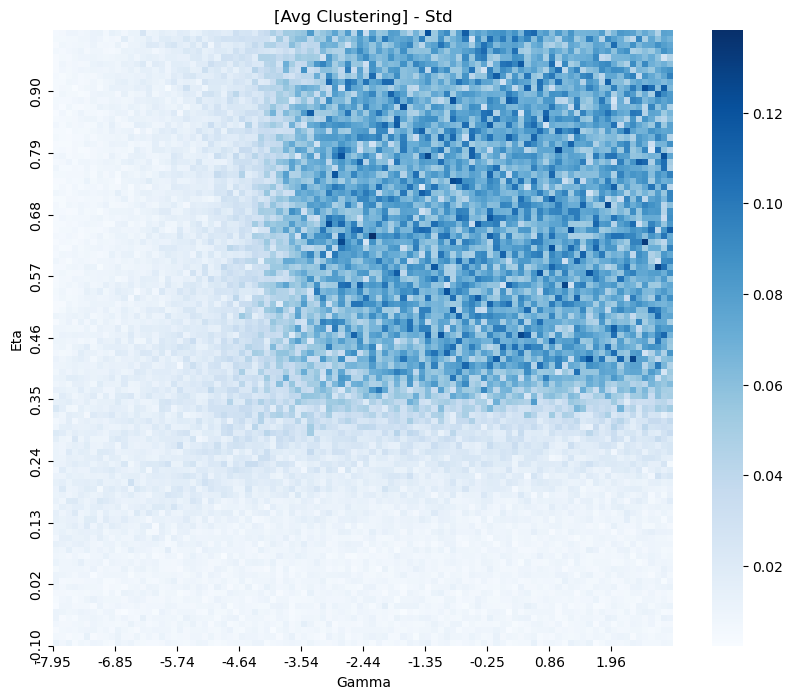

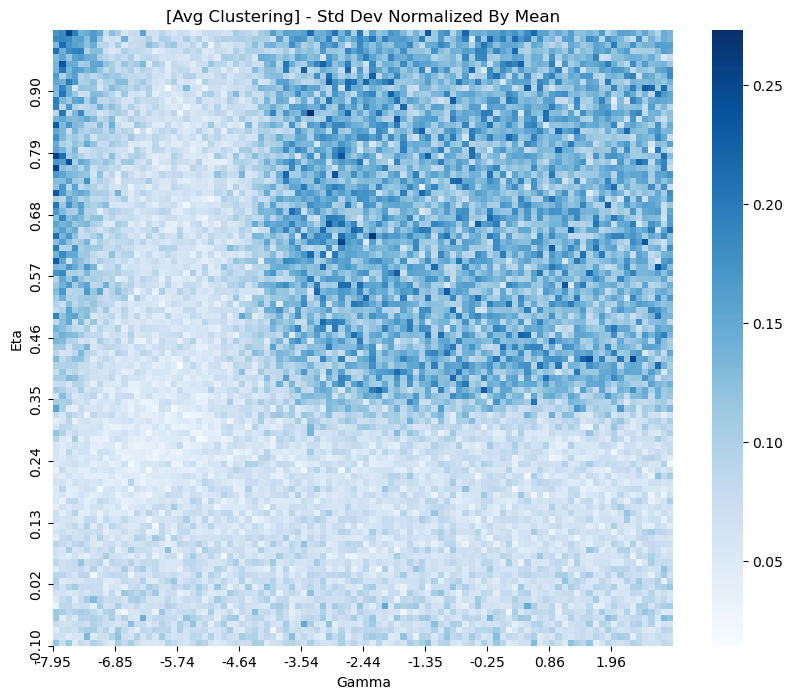

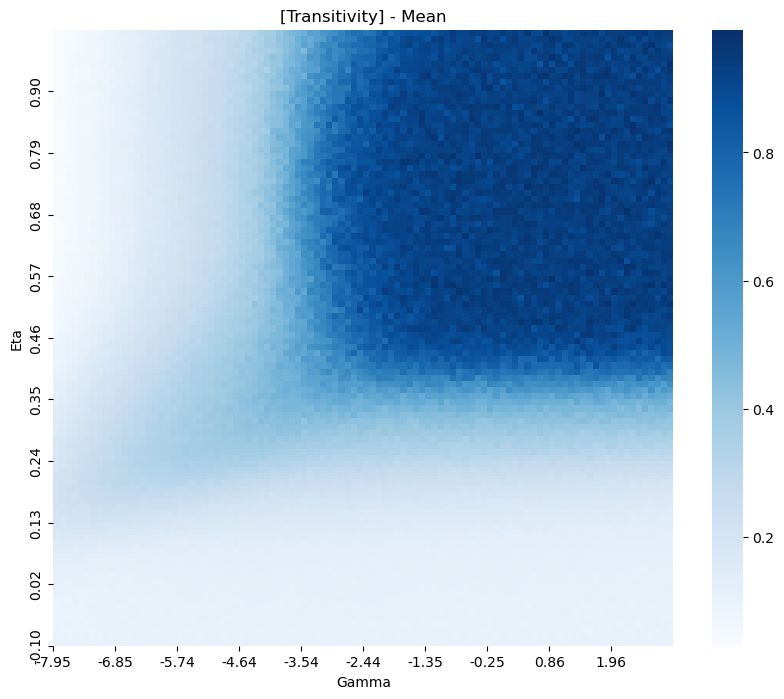

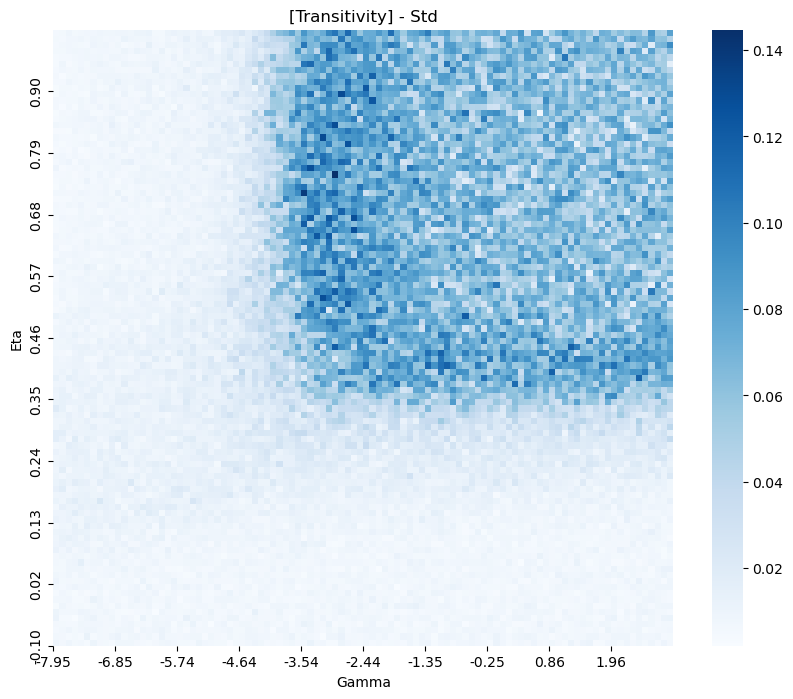

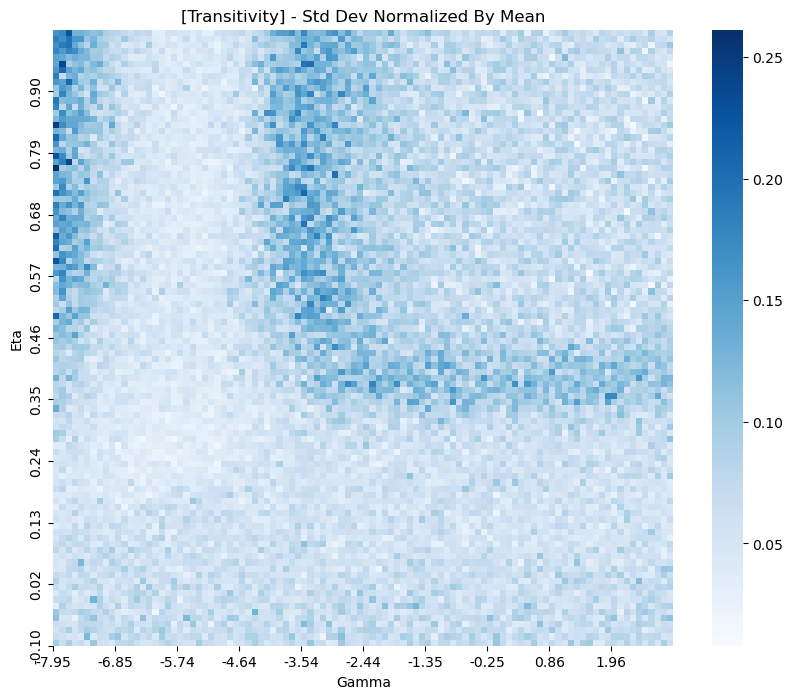

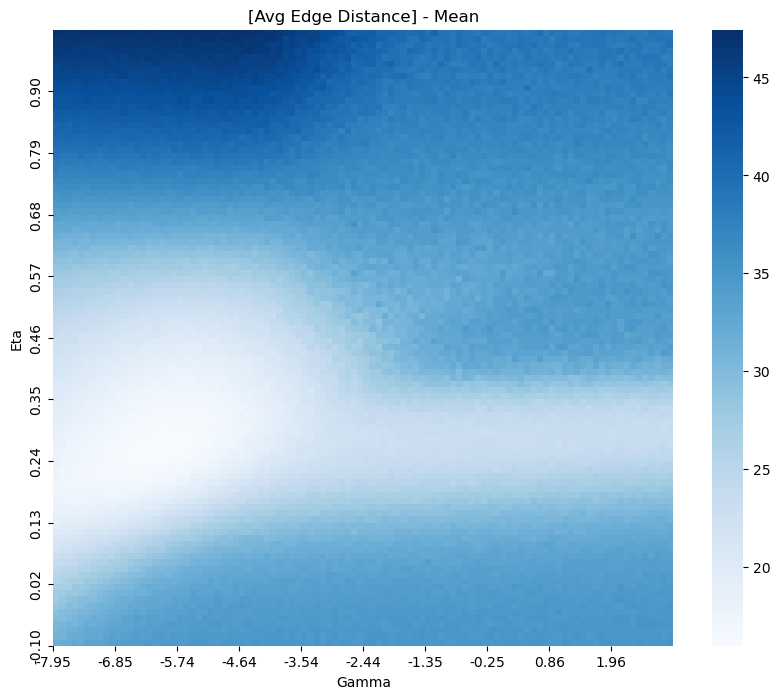

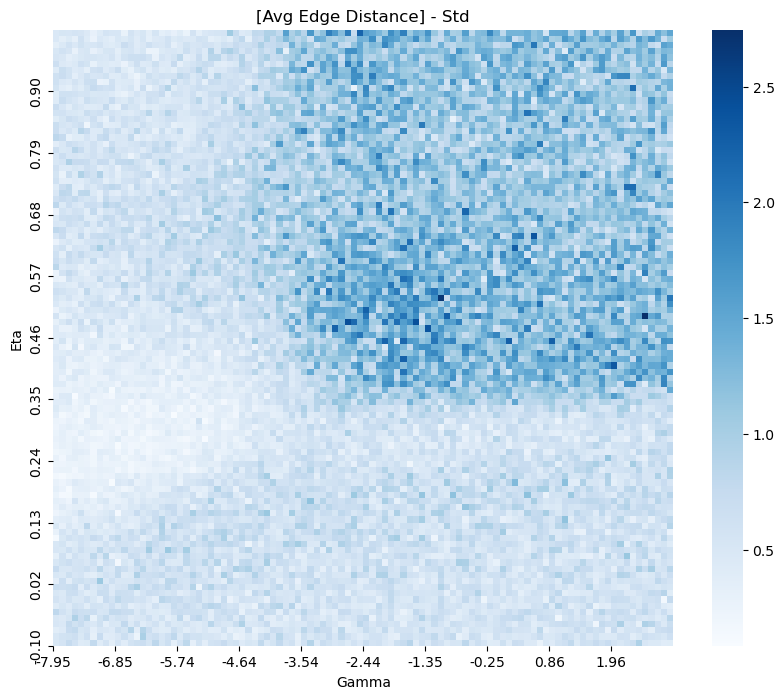

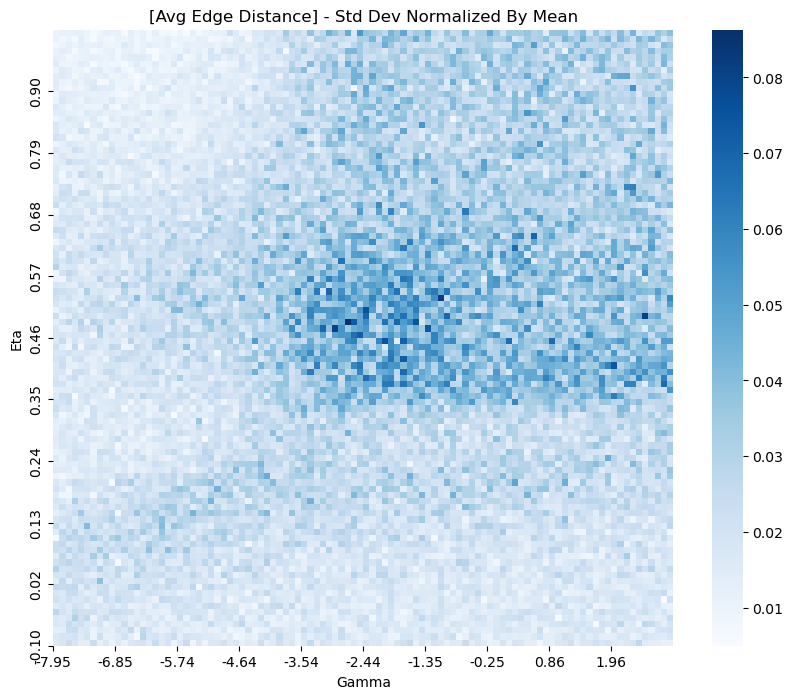

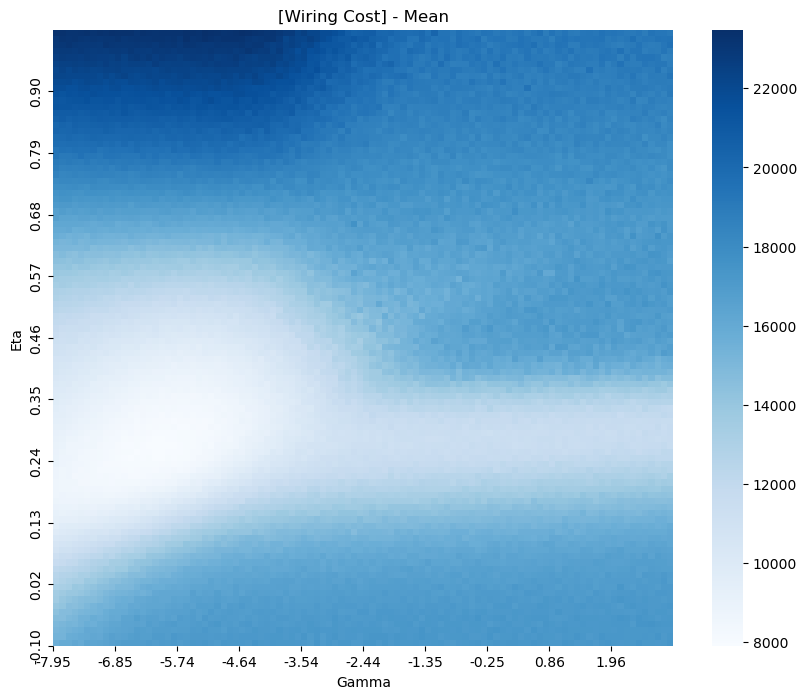

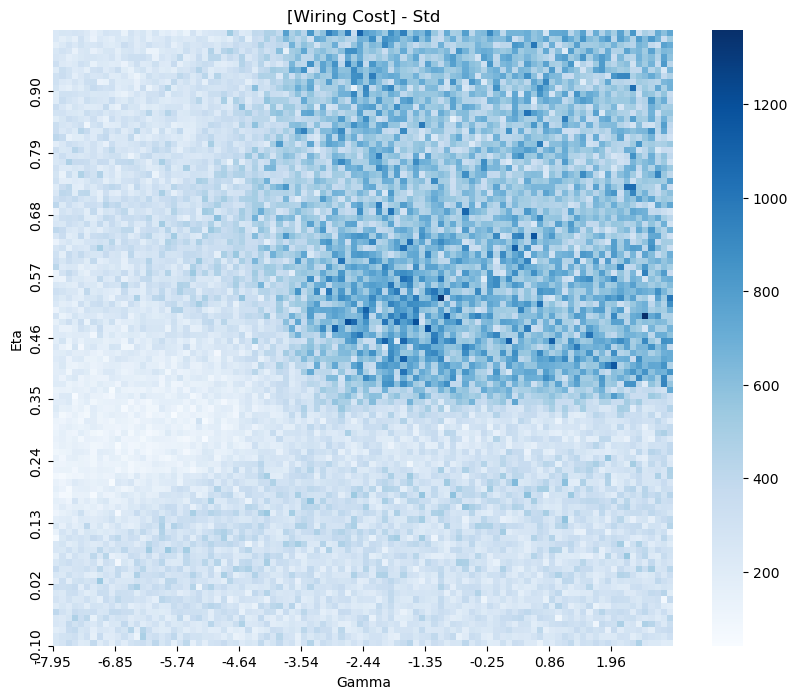

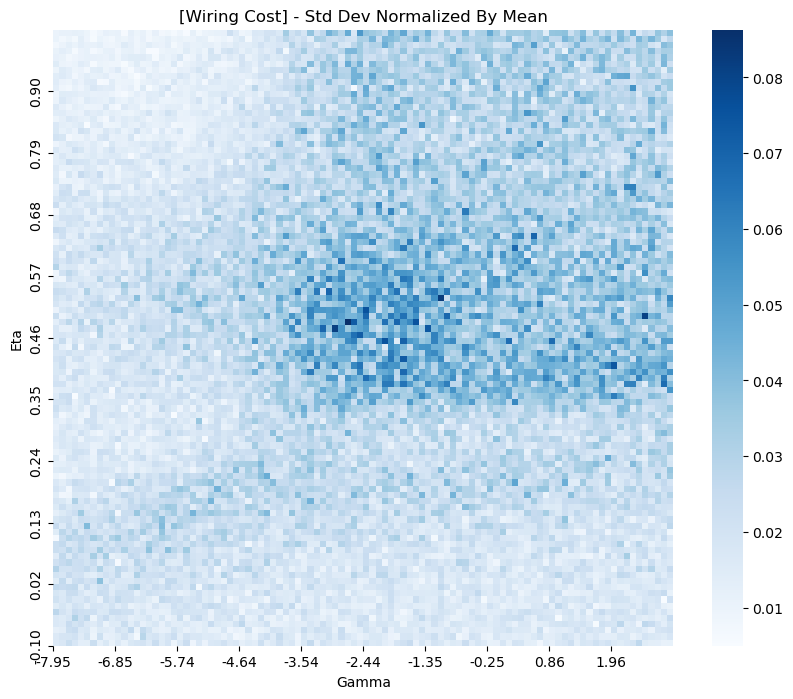

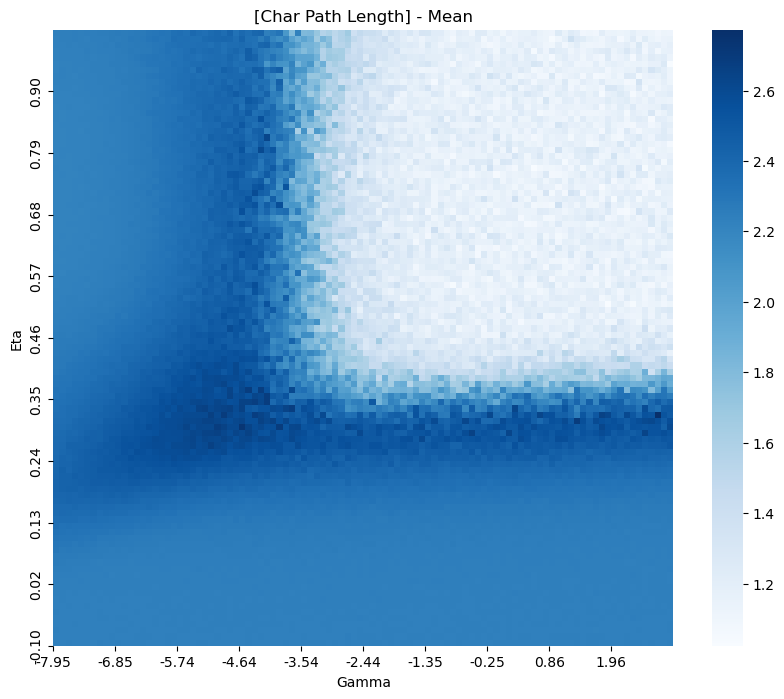

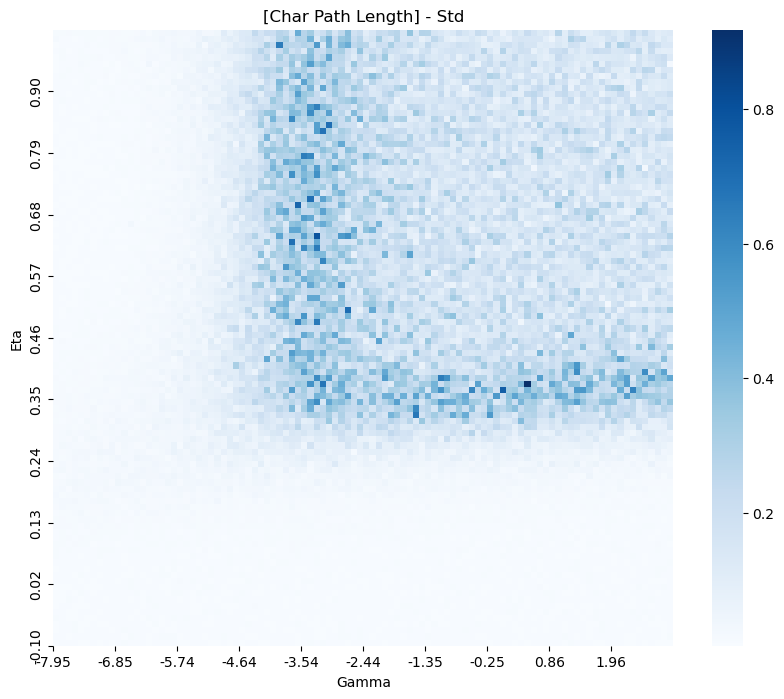

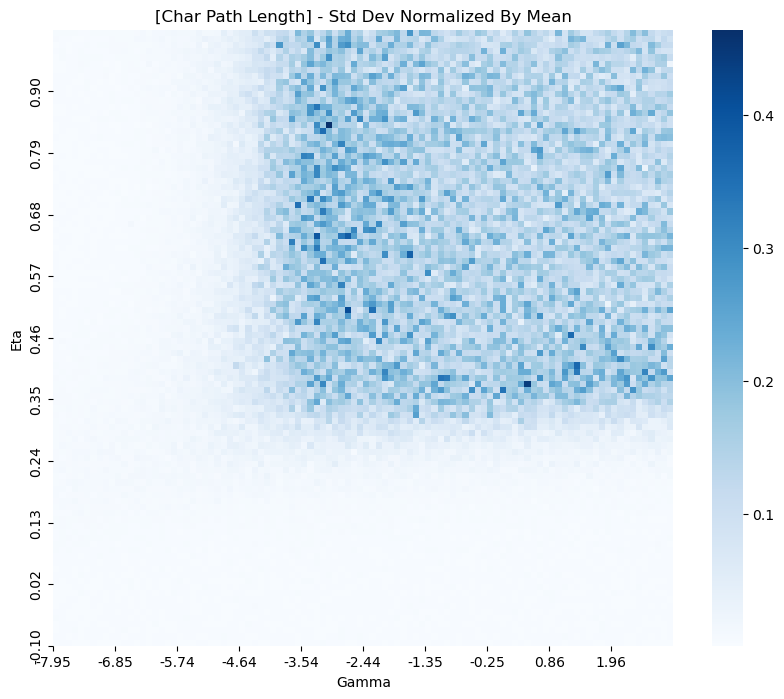

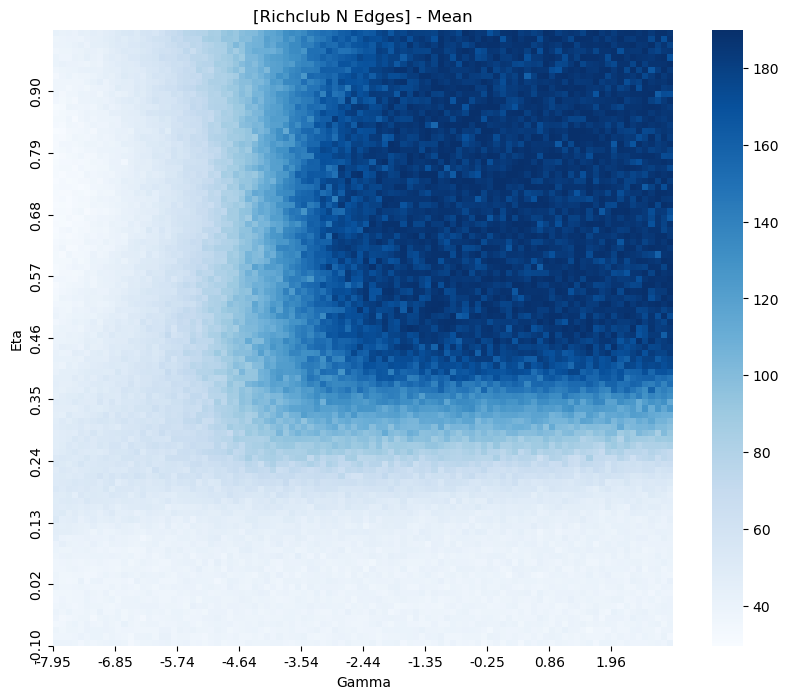

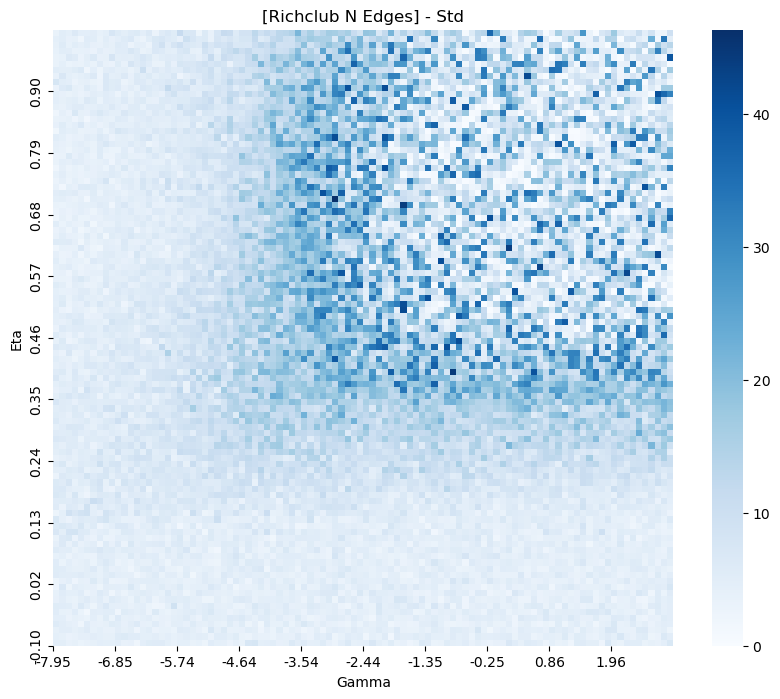

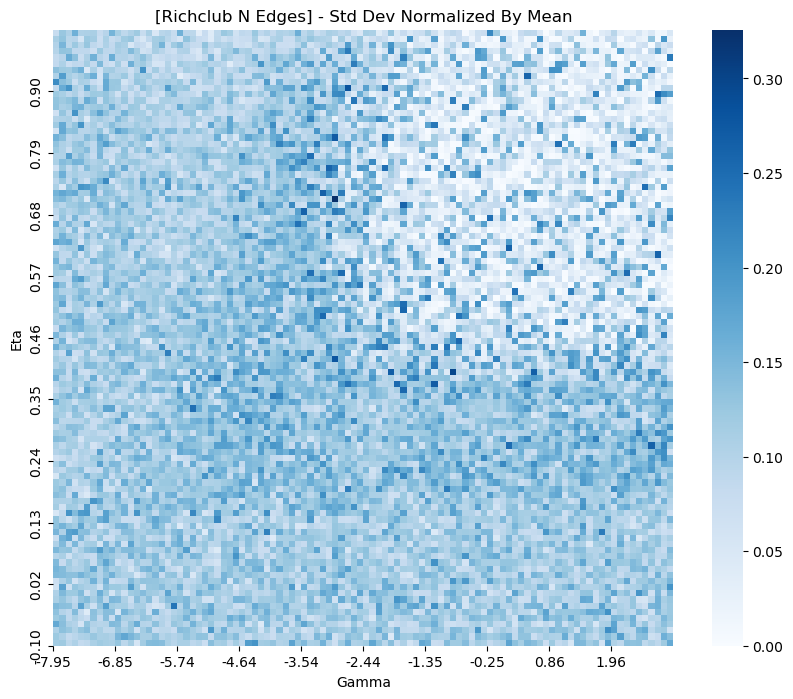

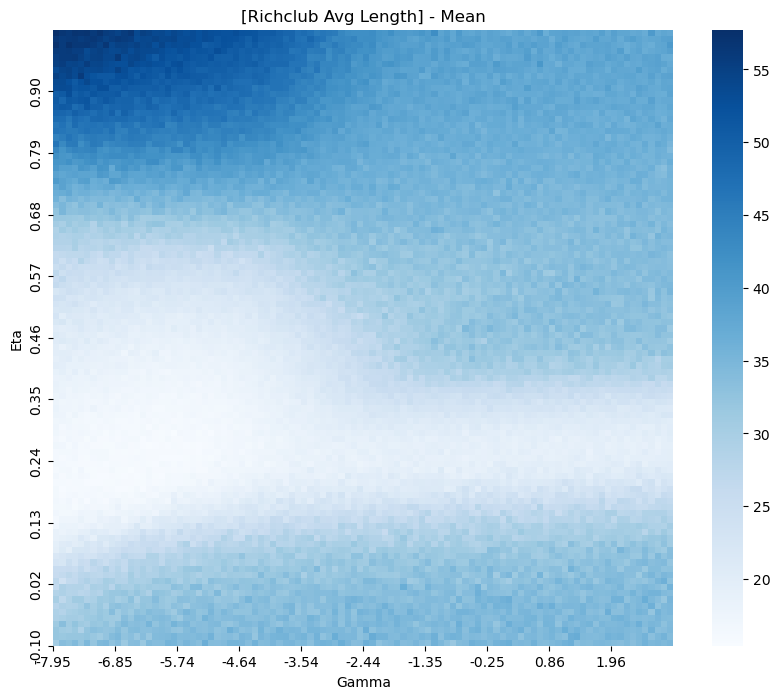

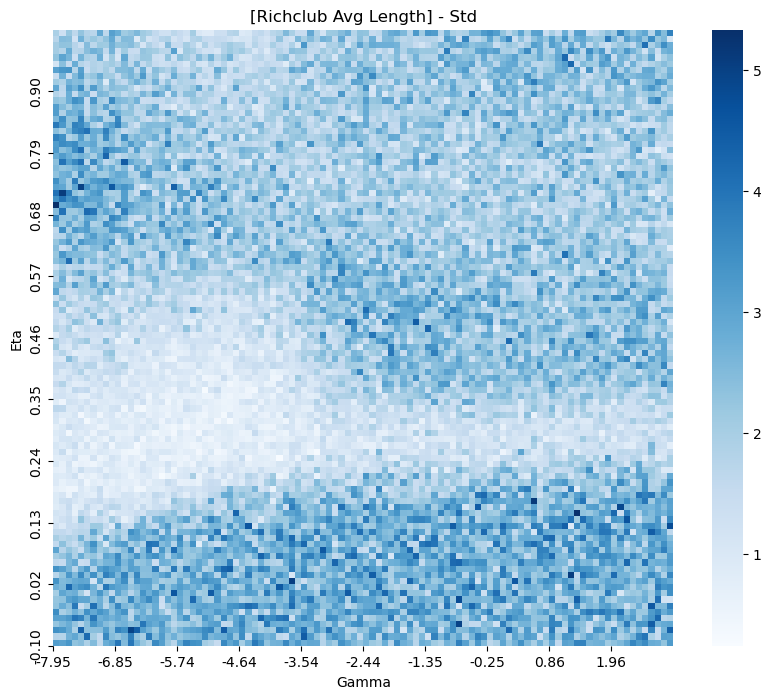

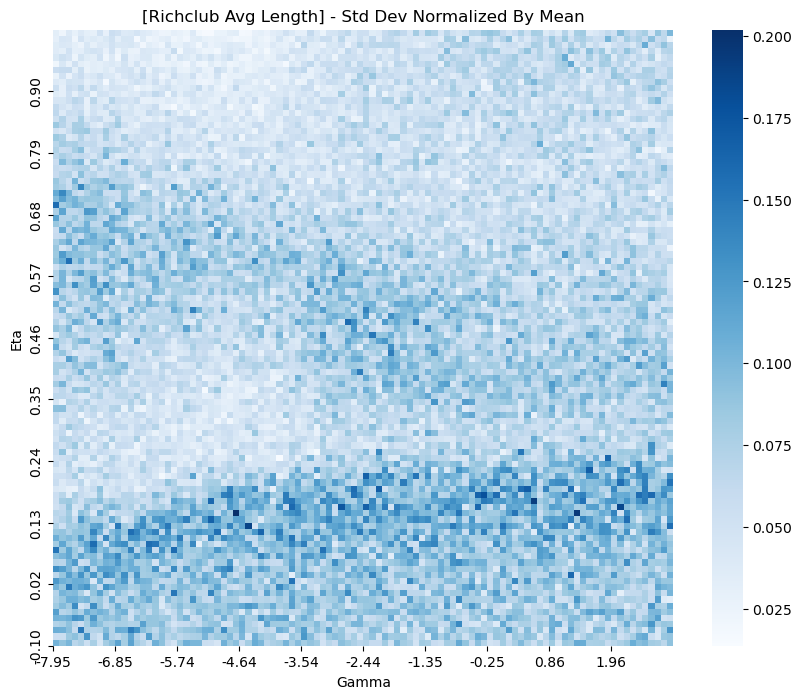

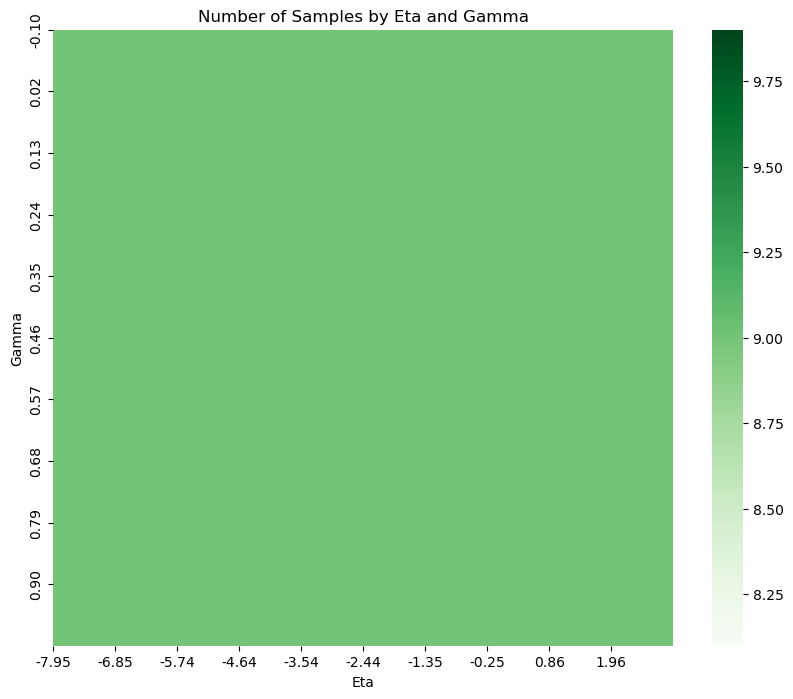

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

def quality_check_regarding_means_and_avgs(path_to_csv_file, bin_into_100=True):
    path_to_csv_file = Path(path_to_csv_file)
    df = pd.read_csv(path_to_csv_file)

    # Define the columns to analyze (excluding eta, gamma, and other metadata)
    metric_columns = [
        'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)',
        'avg_communicability',
        'global_efficiency',
        'modularity',
        'avg_clustering',
        'transitivity',
        'avg_edge_distance',
        'wiring_cost',
        'char_path_length',
        'richclub_n_edges',
        'richclub_avg_length', 
    ]

    # Save original eta and gamma values before binning
    if bin_into_100:
        # Create bins and get bin edges
        eta_bins = pd.cut(df['eta'], bins=100, retbins=True)
        gamma_bins = pd.cut(df['gamma'], bins=100, retbins=True)
        
        # Store original values for mapping
        df['eta_original'] = df['eta']
        df['gamma_original'] = df['gamma']
        
        # Apply binning
        df['eta'] = eta_bins[0].cat.codes
        df['gamma'] = gamma_bins[0].cat.codes
        
        # Create mapping from bin number to representative original value (midpoint of bin)
        eta_bin_centers = (eta_bins[1][:-1] + eta_bins[1][1:]) / 2
        gamma_bin_centers = (gamma_bins[1][:-1] + gamma_bins[1][1:]) / 2
        
    # Group by eta and gamma, then calculate mean and std for each metric
    grouped = df.groupby(['eta', 'gamma'])[metric_columns].agg(['mean', 'std']).reset_index()

    # Display the grouped statistics
    print("Grouped Statistics by Eta and Gamma:")
    print(grouped)
    print(f"\nNumber of unique eta-gamma combinations: {len(grouped)}")

    # Prepare data for heatmaps
    output_folder = path_to_csv_file.parent / 'heatmaps_mean_and_std/'
    os.makedirs(output_folder, exist_ok=True)

    # plot it
    things = ["mean", "std", "std_dev_normalized_by_mean"]
    for metric in metric_columns:
        for thing in things:
            plt.figure(figsize=(10, 8))
            pivot_table = grouped.pivot(index='eta', columns='gamma', values=(metric, thing if thing != "std_dev_normalized_by_mean" else 'std'))
            if thing == "std_dev_normalized_by_mean":
                pivot_table = pivot_table / grouped.pivot(index='eta', columns='gamma', values=(metric, 'mean'))
            sns.heatmap(pivot_table, fmt=".2f", cmap="Blues")
            
            # Invert y-axis
            plt.gca().invert_yaxis()

            plt.title(f'[{metric.replace("_", " ").title()}] - {thing.replace("_", " ").title()}')
            plt.xlabel('Gamma')
            plt.ylabel('Eta')
            
            # Map bin indices back to original values
            if bin_into_100:
                distance = 10
                eta_indices = np.arange(len(pivot_table.columns)//distance)*distance
                gamma_indices = np.arange(len(pivot_table.index)//distance)*distance
                
                # Get original values for the tick positions
                eta_labels = [f"{eta_bin_centers[int(pivot_table.columns[i])]:.2f}" for i in eta_indices]
                gamma_labels = [f"{gamma_bin_centers[int(pivot_table.index[i])]:.2f}" for i in gamma_indices]
                
                plt.xticks(ticks=eta_indices, labels=eta_labels)
                plt.yticks(ticks=gamma_indices, labels=gamma_labels)
            else:
                distance = 10
                plt.xticks(ticks=np.arange(len(pivot_table.columns)//distance)*distance, 
                          labels=[f"{x:.2f}" for x in pivot_table.columns[::distance]])
                plt.yticks(ticks=np.arange(len(pivot_table.index)//distance)*distance, 
                          labels=[f"{y:.2f}" for y in pivot_table.index[::distance]])

            plt.savefig(output_folder / f'{metric}_{thing}.pdf')
            plt.show()
        
    # Similar to the style above: Plot how many samples went into each point in the heatmap
    plt.figure(figsize=(10, 8))
    count_pivot_table = df.groupby(['eta', 'gamma']).size().unstack(fill_value=0)
    sns.heatmap(count_pivot_table, fmt="d", cmap="Greens")
    plt.title('Number of Samples by Eta and Gamma')
    plt.xlabel('Eta')
    plt.ylabel('Gamma')   
    
    # Map bin indices back to original values for count plot
    if bin_into_100:
        distance = 10
        eta_indices = np.arange(len(count_pivot_table.columns)//distance)*distance
        gamma_indices = np.arange(len(count_pivot_table.index)//distance)*distance
        
        eta_labels = [f"{eta_bin_centers[int(count_pivot_table.columns[i])]:.2f}" for i in eta_indices]
        gamma_labels = [f"{gamma_bin_centers[int(count_pivot_table.index[i])]:.2f}" for i in gamma_indices]
        
        plt.xticks(ticks=eta_indices, labels=eta_labels)
        plt.yticks(ticks=gamma_indices, labels=gamma_labels)
    else:
        distance = 10
        plt.xticks(ticks=np.arange(len(count_pivot_table.columns)//distance)*distance, 
                  labels=[f"{x:.2f}" for x in count_pivot_table.columns[::distance]])
        plt.yticks(ticks=np.arange(len(count_pivot_table.index)//distance)*distance, 
                  labels=[f"{y:.2f}" for y in count_pivot_table.index[::distance]])
    
    plt.savefig(output_folder / f'count_samples.pdf')
    plt.show()

# Read the CSV file
path_to_csv_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/all_metrics_for_76_90000_samples_animal_206.csv" 
quality_check_regarding_means_and_avgs(path_to_csv_file, bin_into_100=True)

In [2]:
print(Path(path_to_csv_file).parent)

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206
